# Homework 2

Name: Mariannly Marquez

## 1. Thermodynamics and Heat Conduction (12 points)

Use appropriate numerical algorithms to study how the temperature profile in a heated metal wire evolves in time, under different initial and boundary conditions. For this, you need to numerically solve the 1D heat equation:

$$\frac{\partial T}{\partial t}=\alpha\frac{\partial^2 T}{\partial x^2}$$

where $T=T(x, t)$ describes the temperature of the metal, $x$ is position, $t$ is time, and $\alpha$ is the thermal diffusivity of the metal. We will consider the following metals:

| Metal      | $\alpha$ ($\frac{mm^2}{s}$) |
|------------|--------------------------|
| Copper     | 111                      |
| Iron       | 23                       |
| Aluminum   | 97                       |
| Brass      | 34                       |
| Steel      | 18                       |
| Zinc       | 63                       |
| Lead       | 22                       |
| Titanium   | 9.8                      |

Assume that the metal wire has a length of $20\,\rm cm$, and choose the wire midpoint as the origin for the domain.



In [40]:
# importing libreries

import numpy as np
import matplotlib.pyplot as plt

### Code design:

Organise your code using **python classes** and carry out the following tasks:

**(a)** Place the metals and diffusivities in a python dictionary.


In [41]:
# metals' dict
metals = {
    'Copper': 111,
    'Iron': 23,
    'Aluminum':97,
    'Brass':34,
    'Steel':18,
    'Zinc':63,
    'Lead':22,
    'Titanium':9.8}



**(bx2)** Create a simulation initialisation routine where e.g. the mesh, the initial conditions, and the boundary conditions are all set up.

Consider two types of **initial conditions**:

- **Smooth**, which sets the initial temperature profile in degrees Celsius to be:

$$T(x, 0)= 175 - 50\cos\left(\frac{\pi x}{5}\right) - x^2$$

where $x$ is in units of $\rm cm$. 

- **Noisy**, which adds some noise $f(x)$ with amplitude $\beta$ to the initial condition:

$$T(x, 0)= 175 - 50\cos\left(\frac{\pi x}{5}\right) - x^2 + \beta\,f(x)\,g(x)$$

Note that you need to find an appropriate apodisation function $g(x)$ so that the initial boundary conditions remain fixed at $25\,\rm C$. Similarly, a default amplitude for the noise function can be set to be less than a hundredth of the peak temperature value. 

Also, consider two types of **boundary conditions**:

- **Fixed**, which keep the temperatures at the edges of the metal wire fixed at a temperature of $25\,\rm C$. 
    
- **Varying**, which assume that the boundaries cannot be kept constant (because of e.g. a faulty cooling system). Instead they also evolve in time according to the following functions:

    $T(+10\,{\rm cm}, t) = 25 + 0.12\,t$

    $T(-10\,{\rm cm}, t) = 25 + 0.27\,t$



**(cx3)** Construct a Crank-Nicolson algorithm to simulate **the evolution of an initial temperature profile** and find the **time in seconds at which thermal equilibrium is reached** in an input metal wire (from the dictionary). **Hint:** You need to define some criteria to determine thermal equilibrium.



In [56]:
# Class

class metalconduction:
    def __init__(self, metal):

        #data validation for metal
        if metal not in metals:
            raise ValueError(f"Invalid metal: {metal}. Choose from {list(metals.keys())}")
        else:
            self.metal = metal
            self.conductivity = metals[metal]/100 #in cm^2/s 
        
        self.l = 20 #in cm
        

    def set_conditions(self, h, k, initial_conditions, boundary_conditions, time=100, beta=0.1):
        """
        Set the conditions for the heat equation solver.
        """

        #mesh
        self.dx, self.dt = h,k
        self.r = self.conductivity*k/h**2
        self.x = np.arange(-self.l/2, self.l/2 + self.dx, self.dx)
        self.t = np.arange(0, time + self.dt, self.dt)
        self.n = len(self.x)
        self.m = len(self.t)
        self.T = np.zeros((self.n,self.m))
        self.beta = beta

        #initical conditions (smooth or noisy)
        if initial_conditions == 'smooth':
            self.initial_conditions = 175-50*np.cos(np.pi*self.x/5) - self.x**2
        elif initial_conditions == 'noisy':
            #amplitude
            f = lambda x: np.random.normal(0, 1, self.n) #noise function
            g = lambda x: np.exp(-(x**2)/(2*(self.l/4)**2)) #gaussian apodisation function

            self.initial_conditions = 175-50*np.cos(np.pi*self.x/5) - self.x**2 + self.beta * f(self.x) * g(self.x)
        else:
            raise ValueError("Invalid initial conditions. Choose 'smooth' or 'noisy'.")

        #boundary conditions (fixed or varying)
        if boundary_conditions == 'fixed':
            self.boundary_conditions = [25, 25] #Celsius
        elif boundary_conditions == 'varying':
            self.boundary_conditions = [25 + 0.12 * self.t, 25 + 0.27 * self.t] #Celsius
        else:
            raise ValueError("Invalid boundary conditions. Choose 'fixed' or 'varying'.")

        #adding conditions
        self.T[:, 0] = self.initial_conditions
        self.T[0, :] = self.boundary_conditions[0]
        self.T[-1, :] =self.boundary_conditions[1]

    def solve(self):
        """ 
        Solve heat equation for a 20cm bar of the given material, initial conditions, and 
        boundary conditions using the Crank-Nicolson algorithm.
        """

        #building D1 matrix
        D1_matrix_0 = np.diag([2 + 2*self.r]*(self.n - 2), 0)
        D1_matrix_n = np.diag([-self.r]*(self.n - 3), -1)
        D1_matrix_p = np.diag([-self.r]*(self.n - 3), +1)
        D1_matrix   = D1_matrix_0 + D1_matrix_n + D1_matrix_p

        #building D2 matrix
        D2_matrix_0 = np.diag([2 - 2*self.r]*(self.n - 2), 0)
        D2_matrix_n = np.diag([self.r]*(self.n - 3), -1)
        D2_matrix_p = np.diag([self.r]*(self.n - 3), +1)
        D2_matrix   = D2_matrix_0 + D2_matrix_n + D2_matrix_p

        #building B vector
        for j in range(0, self.m-1):
    
            #add initial conditions to initial b vector
            b = self.T[1:-1, j].copy()
            
            #evaluate RHS
            b = np.dot(D2_matrix, b)
    
            #append missing values
            
            b[0]  = b[0]  + self.r*(self.T[0, j+1] + self.T[0, j])
            b[-1] = b[-1] + self.r*(self.T[-1, j+1] + self.T[-1, j])
            
            #compute the solution vector:
            sln_b = np.linalg.solve(D1_matrix, b)
            
            #update T matrix
            self.T[1:-1, j+1] = sln_b

        return self.T
    
    def get_eq_time(self):
        """
        Calculate the time it takes for the temperature to reach equilibrium.
        """
        #calculate the average temperature at each time step
        avg_temp = np.mean(self.T, axis=0)
        
        #find the time step where the temperature change is less than a threshold
        threshold = 0.005
        flag = True
        for i in range(1, len(avg_temp)):
            if abs(avg_temp[i] - avg_temp[i-1]) < threshold:
                flag = False
                return self.t[i]
        
        if flag:
            raise ValueError("Equilibrium not reached within the given time range.")

### Smooth-Fixed Simulations:

**(d)** Pick **two metal wires** from the dictionary and run both simulations using your Crank-Nicolson algorithm. To compare the results, make a high-quality, 2-column figure showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of each metal wire versus $x$ at a few selected times.



In [57]:
copper_wire = metalconduction('Copper')
copper_wire.set_conditions(h=0.1, k=0.1, initial_conditions='smooth', boundary_conditions='fixed')
copper_T = copper_wire.solve()

In [58]:
titanium_wire = metalconduction('Titanium')
titanium_wire.set_conditions(h=0.1, k=0.1, initial_conditions='smooth', boundary_conditions='fixed')
titanium_T = titanium_wire.solve()

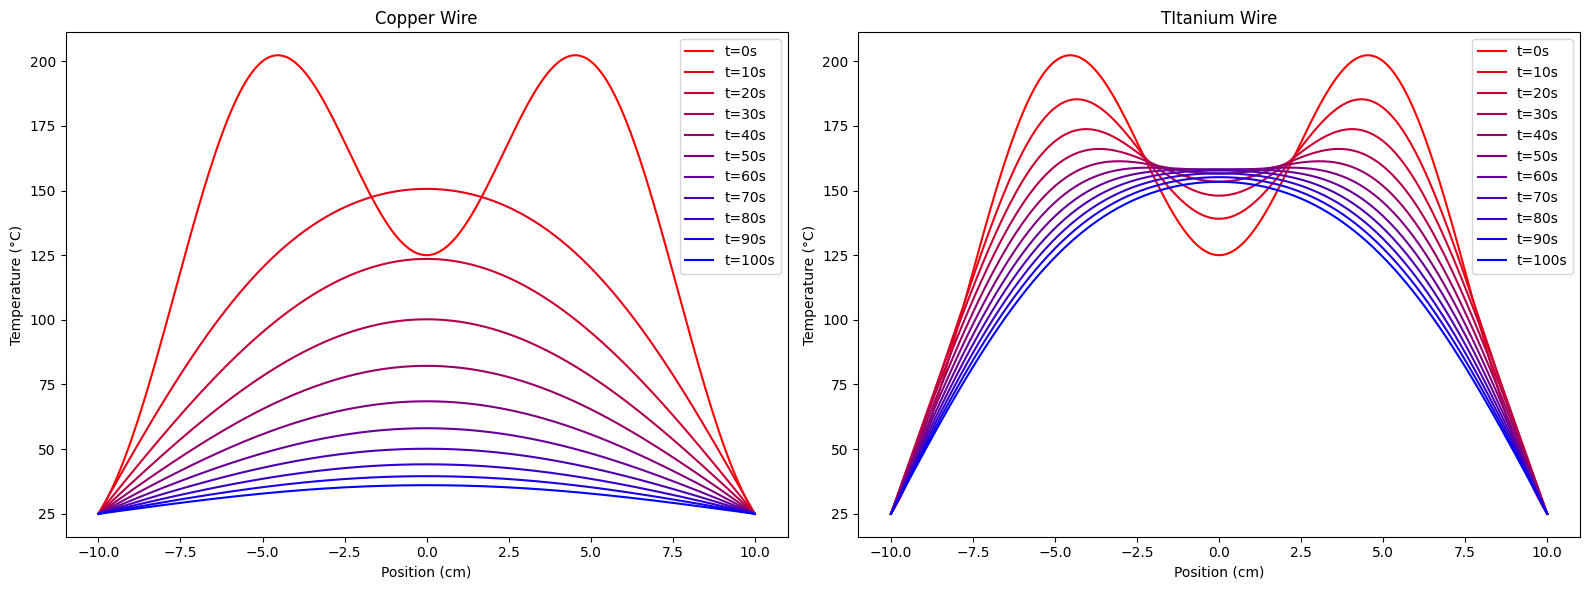

In [59]:
#2 panel plot
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

R = np.linspace(1, 0, len(copper_T[0]))
G = 0
B = np.linspace(0, 1, len(copper_T[0]))

#plotting copper
for i in range(0, len(copper_T[0]), 100):
    axs[0].plot(copper_wire.x, copper_T[:, i], label=f't={copper_wire.t[i]:.0f}s', color=[R[i], G, B[i]])

axs[0].set_title('Copper Wire')
axs[0].set_xlabel('Position (cm)')
axs[0].set_ylabel('Temperature (°C)')
axs[0].legend()

#plotting titanium
for j in range(0, len(titanium_T[0]), 100):
    axs[1].plot(titanium_wire.x, titanium_T[:, j], label=f't={titanium_wire.t[j]:.0f}s', color=[R[j], G, B[j]])

axs[1].set_title('TItanium Wire')
axs[1].set_xlabel('Position (cm)')
axs[1].set_ylabel('Temperature (°C)')
axs[1].legend()

plt.tight_layout()
plt.show()


### Smooth-Fixed versus Noisy-Fixed Simulations:

**(e)** Study heat diffusion only in the Zinc wire considering **smooth versus noisy initial conditions** with noise of 3 different amplitudes. To compare the results, make a high-quality, 4-panel figure (with 2 columns and 2 rows) showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of the Zinc metal wire versus $x$ at a few selected times, under different initial conditions (smooth vs. 3 noisy cases).



In [60]:
#smooth
zinc_smooth = metalconduction('Zinc')
zinc_smooth.set_conditions(h=0.1, k=0.1, initial_conditions='smooth', boundary_conditions='fixed', time =300)
zinc_T_smooth = zinc_smooth.solve()

#noisy
zinc_noisy1 = metalconduction('Zinc')
zinc_noisy1.set_conditions(h=0.1, k=0.1, initial_conditions='noisy', boundary_conditions='fixed', time =300, beta=0.5)
zinc_T_noisy1 = zinc_noisy1.solve()

zinc_noisy2 = metalconduction('Zinc')
zinc_noisy2.set_conditions(h=0.1, k=0.1, initial_conditions='noisy', boundary_conditions='fixed', time =300, beta=5)
zinc_T_noisy2 = zinc_noisy2.solve()

zinc_noisy3 = metalconduction('Zinc')
zinc_noisy3.set_conditions(h=0.1, k=0.1, initial_conditions='noisy', boundary_conditions='fixed', time =300, beta=20)
zinc_T_noisy3 = zinc_noisy3.solve()


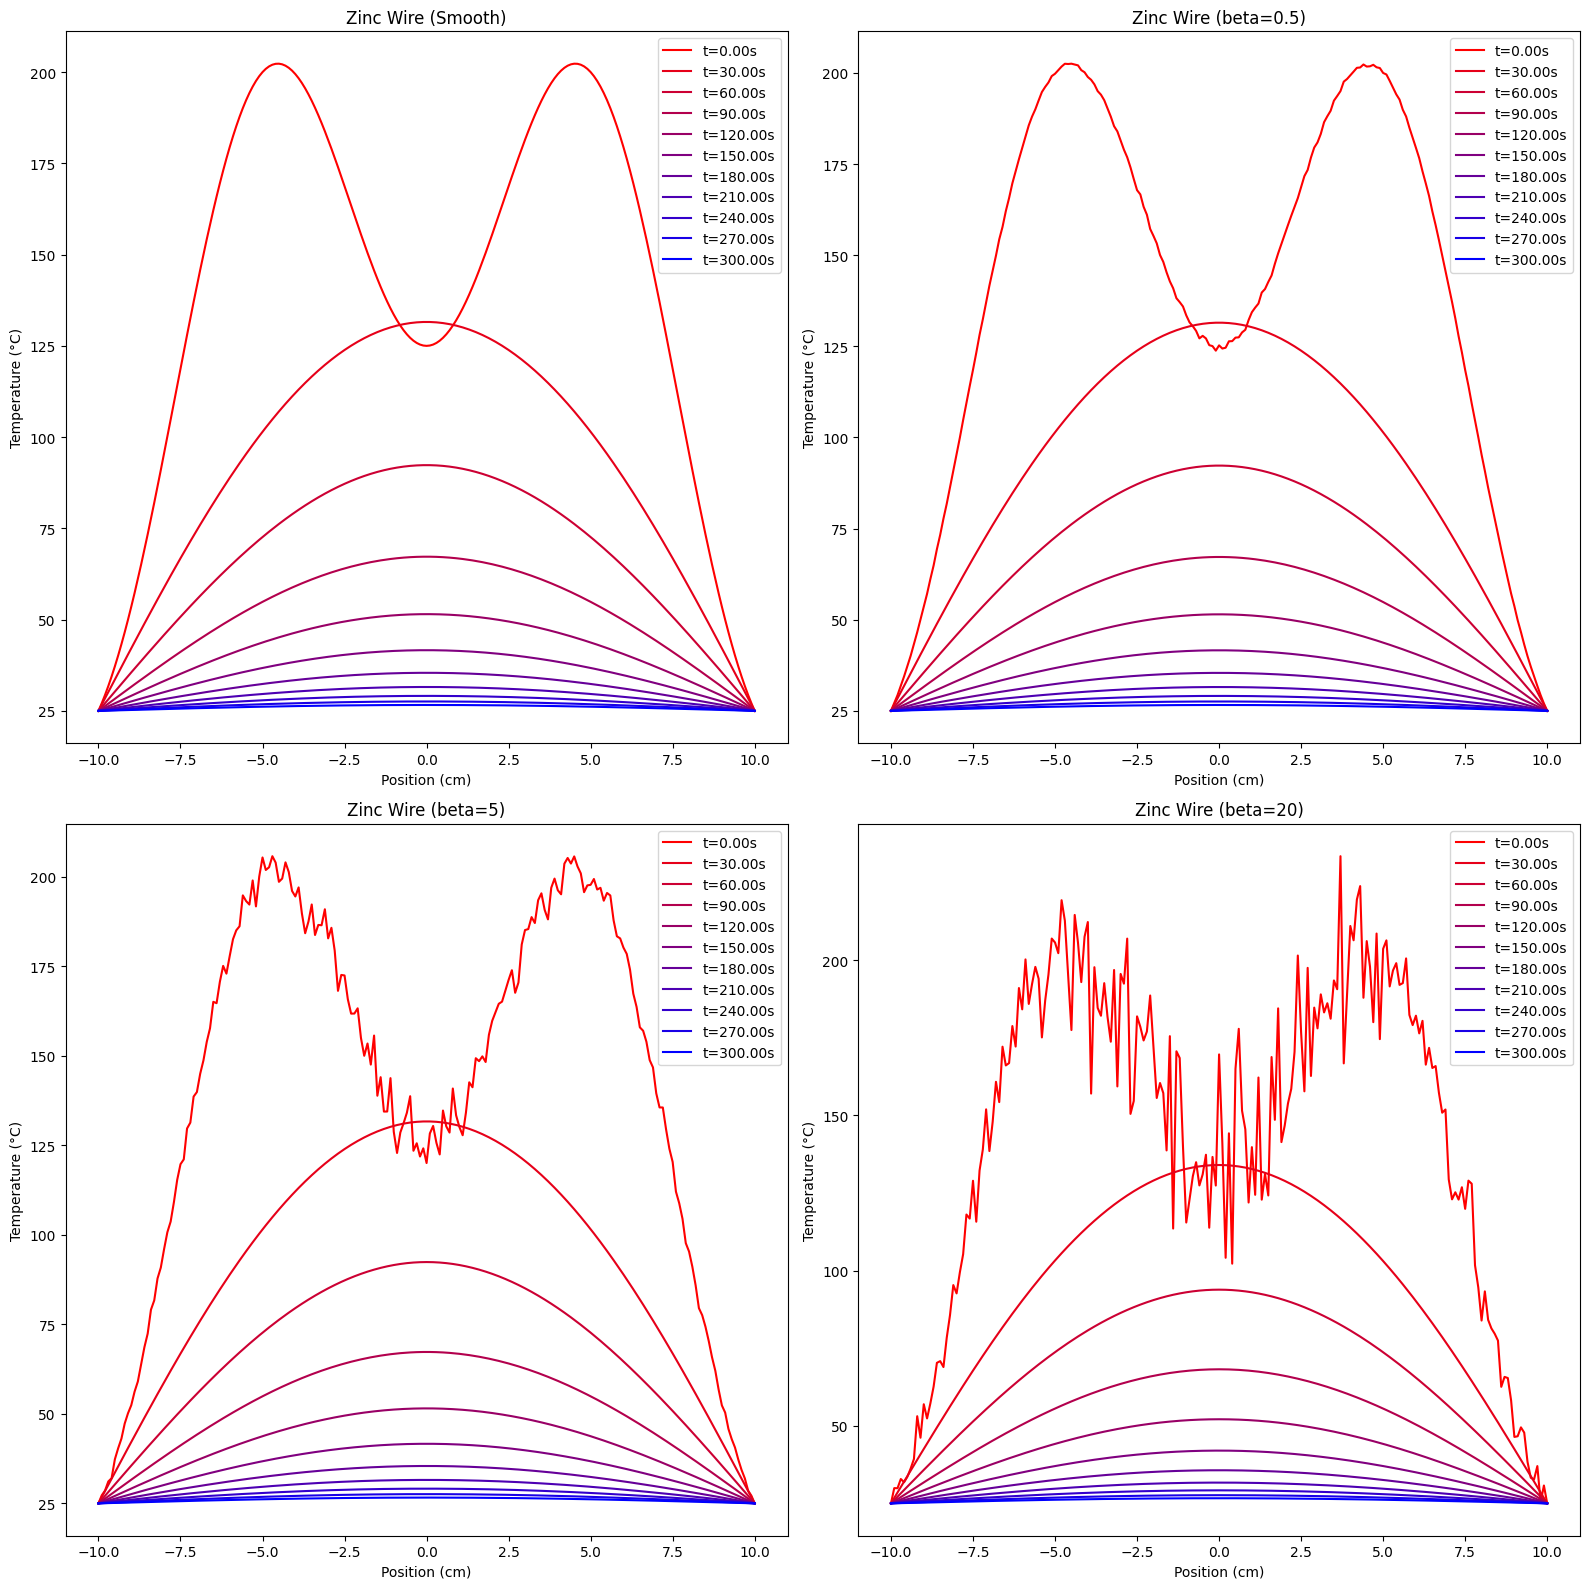

In [61]:
#4 panel plot
fig, axs = plt.subplots(2, 2, figsize=(16, 16))

R = np.linspace(1, 0, len(zinc_T_smooth[0]))
G = 0
B = np.linspace(0, 1, len(zinc_T_smooth[0]))

#plotting smooth
for i in range(0, len(zinc_T_smooth[0]), 300):
    axs[0, 0].plot(zinc_smooth.x, zinc_T_smooth[:, i], label=f't={zinc_smooth.t[i]:.2f}s', color=[R[i], G, B[i]])

axs[0, 0].set_title('Zinc Wire (Smooth)')
axs[0, 0].set_xlabel('Position (cm)')
axs[0, 0].set_ylabel('Temperature (°C)')
axs[0, 0].legend()

#plotting noisy1
for j in range(0, len(zinc_T_noisy1[0]), 300):
    axs[0, 1].plot(zinc_noisy1.x, zinc_T_noisy1[:, j], label=f't={zinc_noisy1.t[j]:.2f}s', color=[R[j], G, B[j]])

axs[0, 1].set_title(f'Zinc Wire (beta={zinc_noisy1.beta})')
axs[0, 1].set_xlabel('Position (cm)')
axs[0, 1].set_ylabel('Temperature (°C)')
axs[0, 1].legend()

#plotting noisy2
for j in range(0, len(zinc_T_noisy2[0]), 300):
    axs[1, 0].plot(zinc_noisy2.x, zinc_T_noisy2[:, j], label=f't={zinc_noisy2.t[j]:.2f}s', color=[R[j], G, B[j]])

axs[1, 0].set_title(f'Zinc Wire (beta={zinc_noisy2.beta})')
axs[1, 0].set_xlabel('Position (cm)')
axs[1, 0].set_ylabel('Temperature (°C)')
axs[1, 0].legend()

#plotting noisy3
for j in range(0, len(zinc_T_noisy3[0]), 300):
    axs[1, 1].plot(zinc_noisy3.x, zinc_T_noisy3[:, j], label=f't={zinc_noisy3.t[j]:.2f}s', color=[R[j], G, B[j]])

axs[1, 1].set_title(f'Zinc Wire (beta={zinc_noisy3.beta})')
axs[1, 1].set_xlabel('Position (cm)')
axs[1, 1].set_ylabel('Temperature (°C)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

### Smooth-Fixed versus Smooth-Varying Simulations:

**(f)** Study heat diffusion only in the Aluminum wire considering **fixed versus varying boundary conditions**. To compare the results, make a high-quality, 2-column figure showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of the Aluminum metal wire versus $x$ at a few selected times, under different boundary conditions.


In [62]:
aluminum_fixed = metalconduction('Aluminum')
aluminum_fixed.set_conditions(h=0.1, k=0.1, initial_conditions='smooth', boundary_conditions='fixed')
aluminum_T_fixed = aluminum_fixed.solve()

aluminum_varying = metalconduction('Aluminum')
aluminum_varying.set_conditions(h=0.1, k=0.1, initial_conditions='smooth', boundary_conditions='varying')
aluminum_T_varying = aluminum_varying.solve()

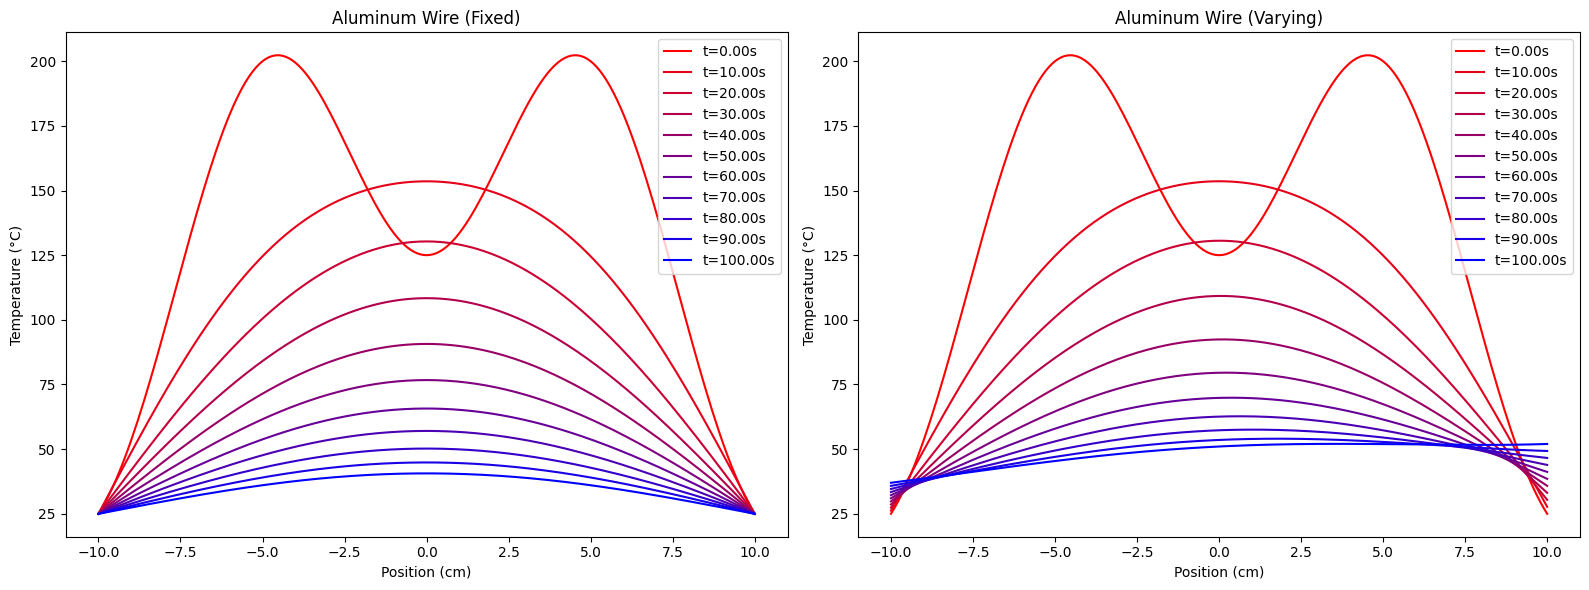

In [63]:
#4 panel plot
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

R = np.linspace(1, 0, len(aluminum_T_fixed[0]))
G = 0
B = np.linspace(0, 1, len(aluminum_T_fixed[0]))

#plotting fixed
for i in range(0, len(aluminum_T_fixed[0]), 100):
    axs[0].plot(aluminum_fixed.x, aluminum_T_fixed[:, i], label=f't={aluminum_fixed.t[i]:.2f}s', color=[R[i], G, B[i]])

axs[0].set_title('Aluminum Wire (Fixed)')
axs[0].set_xlabel('Position (cm)')
axs[0].set_ylabel('Temperature (°C)')
axs[0].legend()

#plotting varying
for j in range(0, len(aluminum_T_varying[0]), 100):
    axs[1].plot(aluminum_varying.x, aluminum_T_varying[:, j], label=f't={aluminum_varying.t[j]:.2f}s', color=[R[j], G, B[j]])

axs[1].set_title('Aluminum Wire (Varying)')
axs[1].set_xlabel('Position (cm)')
axs[1].set_ylabel('Temperature (°C)')
axs[1].legend()

plt.tight_layout()
plt.show()

### Analysis:

**(g)** Can we use explicit or FFT methods to solve this problem? Explain.

Yes, however, they have limitations. Explicit methods might become unstable for large time steps. And FFT methods are not suitable for non-periodic boundary conditions. 

**(h)** Does the input noise amplitude change the time at which thermal equilibrium is reached or not? Why?


In [64]:
print(f"Time to reach equilibrium for zinc wire with different levels of noise is: {zinc_noisy1.get_eq_time():.2f}s (beta={zinc_noisy1.beta}), {zinc_noisy2.get_eq_time():.2f}s (beta={zinc_noisy2.beta}), {zinc_noisy3.get_eq_time():.2f}s (beta={zinc_noisy3.beta})")

Time to reach equilibrium for zinc wire with different levels of noise is: 226.30s (beta=0.5), 226.40s (beta=5), 227.80s (beta=20)


It seems to have a minimal effect on the time at which thermal equilibrium is reached. It seems to be mainly determined by the thermal diffusivity of the material and the boundary conditions.

**(i)** What is the effect of a faulty cooling system on the temperature profile?

It seems to make the wire less effective at reaching thermal equilibrium. The temperature is more uneven and takes longer to reach a steady state.

## 2. Joblib Parallelisation (8 points)

Consider the same statement provided in problem 1. All code should be organised in **python classes**.

### Parallelisation with joblib:

**(a)** Imagine we wish to run several simulations in parallel for the metals included in the dictionary. Within the **metalconduction.ipynb** notebook, create a routine that uses ```joblib``` to parallelise the simulation executions in $n$ CPUs.


In [71]:
# joblib
import joblib
import time
import os

In [72]:
# cpus
os.cpu_count()

4

In [ ]:
#parallelise for different metals 
def parallel_metal_conduction(metal):
    
    metal_conduction = metalconduction(metal)
    metal_conduction.set_conditions(h=0.1, k=0.1, initial_conditions='smooth', boundary_conditions='fixed')

    return metal_conduction.solve()


**(b)** Test your implementation by running $2$ simulations ($1$ for Iron and $1$ for Lead) first in serial and then in parallel (simultaneously). For the serial run, $n=1$ CPU core. For the parallel run, $n=2$ CPU cores. The time should go down. **Hint:** You need to add time stamps to quantify and return log files with the execution times. 


In [ ]:
#metals
metals_list = ['Iron', 'Lead']

#Serial
#start time
start_time0 = time.time()
#processing
results_serial = joblib.Parallel(n_jobs=1)(joblib.delayed(parallel_metal_conduction)(metal) for metal in metals_list)
#end time
end_time0 = time.time()

#print time
time0 = end_time0 - start_time0
print(f"Execution time for serial processing: {time0:.2f} s")

#Parallel
#start time
start_time1 = time.time()
#processing
results_parallel = joblib.Parallel(n_jobs=2)(joblib.delayed(parallel_metal_conduction)(metal) for metal in metals_list)
#end time
end_time1 = time.time()

#print time
time1 = end_time1 - start_time1
print(f"Execution time for parallel processing: {time1:.2f} s")


Execution time for serial processing: 3.62 s
Execution time for parallel processing: 1.44 s



**(c)** Make a scaling plot showing (serial and parallel) execution times in the $Y$ axis versus the number of CPU cores ($n$) in the $X$ axis.


In [76]:
#parallel with 3 cpus
start_time2 = time.time()
results_parallel_3 = joblib.Parallel(n_jobs=3)(joblib.delayed(parallel_metal_conduction)(metal) for metal in metals_list)
end_time2 = time.time()
time2 = end_time2 - start_time2

#parallel with 4 cpus
start_time3 = time.time()
results_parallel_4 = joblib.Parallel(n_jobs=4)(joblib.delayed(parallel_metal_conduction)(metal) for metal in metals_list)
end_time3 = time.time()
time3 = end_time3 - start_time3

Exception ignored in: <function ResourceTracker.__del__ at 0x7f7302c2f100>
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/usr/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/usr/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f102e437100>
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/usr/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/usr/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes


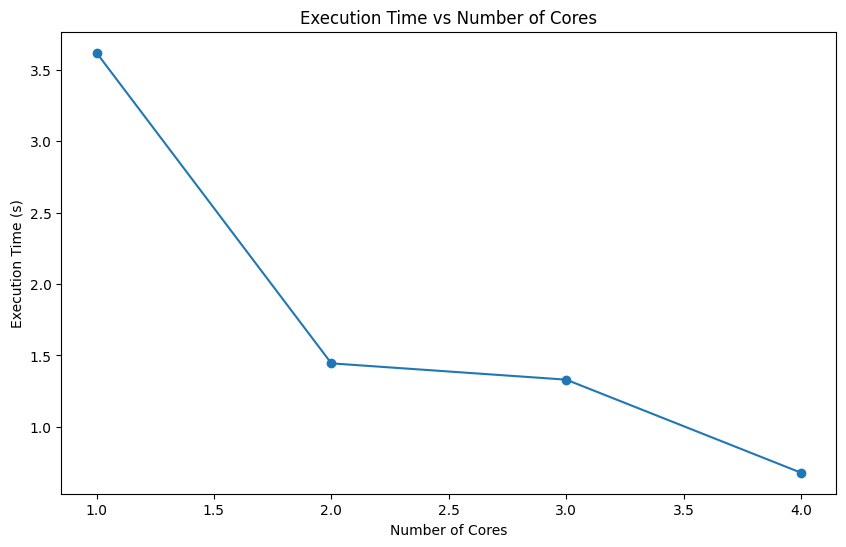

In [77]:
plt.figure(figsize=(10, 6))

#plotting execution time vs number of cores
plt.plot([1, 2, 3, 4], [time0, time1, time2, time3], marker='o')

plt.title('Execution Time vs Number of Cores')
plt.xlabel('Number of Cores')
plt.ylabel('Execution Time (s)')

plt.show()
